# Machine learning model 

In [2]:
#Tools used for model training and evaluation 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

#Load data

df = pd.read_csv("c:/Users/felip/drug-likeness-project/data/B3DB_clean.csv")

print("Shape:", df.shape)
df.head()

Shape: (7807, 6)


,compound_name,BBB+/BBB-,MW,LogP,HBD,HBA
0,sulphasalazine,BBB-,398.400,3.70160,3.0,7.0
1,moxalactam,BBB-,520.480,-1.12770,4.0,12.0
2,clioquinol,BBB-,305.502,3.19840,1.0,2.0
3,bbcpd11 (cimetidine analog) (y-g13),BBB-,342.266,2.11348,2.0,4.0
4,schembl614298,BBB-,461.467,-1.23650,5.0,9.0


In [3]:
#X; charactiristics

X = df[["MW", "LogP", "HBD", "HBA"]]

#Y; prediction

y = df["BBB+/BBB-"].map({"BBB+": 1, "BBB-": 0})


In [4]:
#Training and testing split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 6245
Testing rows: 1562


In [5]:
#Model used

model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
#Predict

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] 


In [7]:
#Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names = ["BBB-", "BBB+"]))

Accuracy: 86.75%

Detailed Report:
              precision    recall  f1-score   support

        BBB-       0.86      0.76      0.81       570
        BBB+       0.87      0.93      0.90       992

    accuracy                           0.87      1562
   macro avg       0.87      0.85      0.85      1562
weighted avg       0.87      0.87      0.87      1562



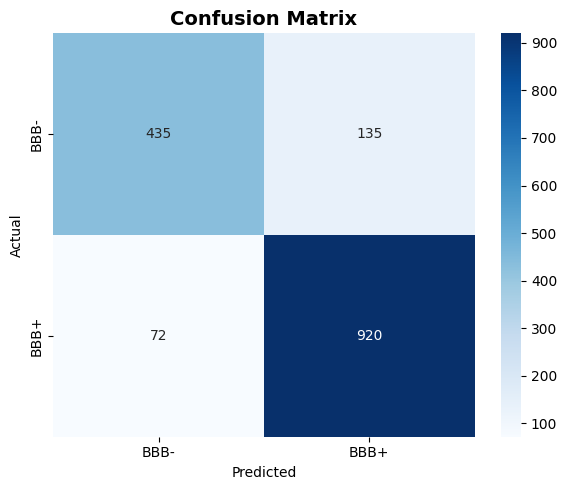

In [8]:
#Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["BBB-", "BBB+"],
    yticklabels = ["BBB-", "BBB+"]
)
plt.title("Confusion Matrix", fontsize = 14, fontweight = "bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

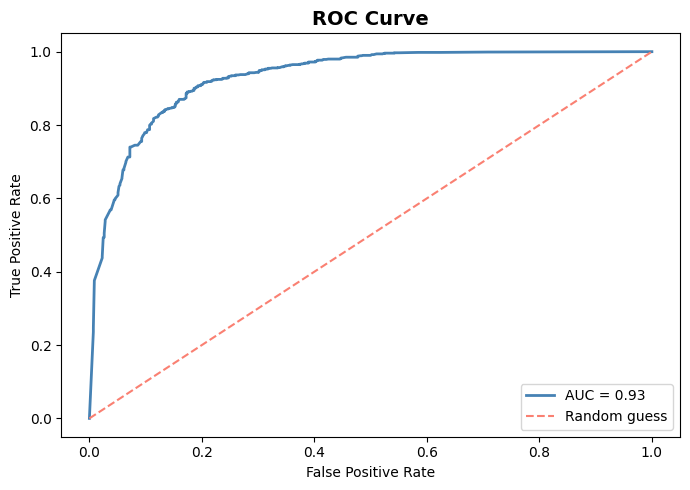

In [9]:
#ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], color="salmon", linestyle="--", label="Random guess")
plt.title("ROC Curve", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_10300\3392860416.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


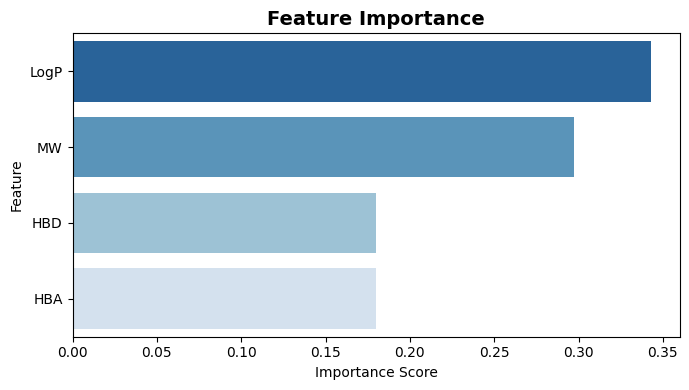

  feature  importance
1    LogP      0.3430
0      MW      0.2970
2     HBD      0.1801
3     HBA      0.1799


In [10]:
#Importance for each charactiristic

importance = pd.DataFrame({
    "feature": ["MW", "LogP", "HBD", "HBA"],
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=importance,
    x="importance",
    y="feature",
    palette="Blues_r"
)
plt.title("Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(importance.round(4))

In [12]:
#Prepare for visualization

results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred
results["probability_BBB+"] = y_prob

results["actual_label"] = results["actual"].map({1: "BBB+", 0: "BBB-"})
results["predicted_label"] = results["predicted"].map({1: "BBB+", 0: "BBB-"})
results["correct"] = results["actual"] == results["predicted"]

results.to_csv("c:/Users/felip/drug-likeness-project/data/ml_results.csv", index=False)
results.head(30)

importance.to_csv("c:/Users/felip/drug-likeness-project/data/feature_importance.csv", index=False)
